In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%matplotlib inline
from vmm_tools import combineDataFrames, combineDataFramesMajd, fiducializeArea

In [2]:
'''--------------------------MATPLOTLIB PLOT PARAMETERS--------------------------'''

plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 2,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
})

In [3]:
'''----------------------------------FUNCTIONS----------------------------------'''

#compute number of electrons in event to find and plot gain, then do a best fit to the data
# Per Lucian, 1 ADC ~ 1 mV
def histGain(ax, df_clusters, gain_color, hist_label, x_gain, y_gain, xaxis_minmax, fiducialize=False, fid_area='a', data_duration=None): #change area to desired section of the micromegas, see vmm_tools.py for options
    #6240 comes from 1 fC = 6240 electrons
    df_clusters["electrons_x"] = df_clusters['adc0'].apply(lambda x: 6240 * ( x  / x_gain ) )
    df_clusters["electrons_y"] = df_clusters['adc1'].apply(lambda x: 6240 * ( x / y_gain ) )
    df_clusters["electrons"] = df_clusters['electrons_x'] + df_clusters['electrons_y']
    df_clusters["gain"] = df_clusters["electrons"] / 167.5 #167.5 is the average number of primary electrons created by a 5.9 keV X-ray in Ar/CO2 70:30
    if fiducialize == True:
        areaName = fid_area
        df_clusters = fiducializeArea(df_clusters, area=areaName)
        pass
    elif fiducialize == False:
        areaName = 'all_areas'
        pass
    else:
        raise Exception("Pick a valid value for fiducialize, either True or False")
    
    gain = df_clusters['gain']
    nbins = 100
    counts, bin_edges, patches = ax.hist(gain,nbins,range=xaxis_minmax, color=gain_color, histtype='step', label=hist_label, weights=np.full(len(gain), 1/data_duration), linewidth=2.5)
    
    return counts, bin_edges, patches

#plot cluster positions in a 2D histogram
def plotClusterLocations2D(ax, df_clusters, strip_edges, data_duration, logscale=False):
    pos0Data = df_clusters['pos0']
    pos1Data = df_clusters['pos1']

    if logscale == True:
        hist, xedges, yedges, im = ax.hist2d(pos0Data, pos1Data, bins=[strip_edges,strip_edges], cmap=plt.cm.jet, norm=LogNorm())
    elif logscale == False:
        hist, xedges, yedges, im = ax.hist2d(pos0Data, pos1Data, bins=[strip_edges,strip_edges], cmap=plt.cm.jet, cmin=1) #cmin=1 is to mask 0 count bins when linearscale)
    im.set_array(hist.T / data_duration)  # Convert to counts per second
    im.autoscale()  # Rescale color limits

    return hist, xedges, yedges, im

#calculate the charge sharing (defined as # electrons in x / # electrons in y)
def calculateChargeSharing(df_clusters, x_gain, y_gain, fiducialize=False, fid_area='a'):
    df_clusters["electrons_x"] = df_clusters['adc0'].apply(lambda x: 6240 * ( x  / x_gain ) ) # 9 mV/fC is VMM gain setting for x channels, 170mV is the pedestal, 1200mV is th operating voltage 1024 is the number of possible ADC values
    df_clusters["electrons_y"] = df_clusters['adc1'].apply(lambda x: 6240 * ( x / y_gain ) ) # 4.5 mV/fC is VMM gain setting for y channels, 170mV is the pedestal, 1200mV is th operating voltage 1024 is the number of possible ADC values

    if fiducialize == True:
        areaName = fid_area
        df_clusters = fiducializeArea(df_clusters, area=areaName)
        pass
    elif fiducialize == False:
        areaName = 'all_areas'
        pass
    else:
        raise Exception("Pick a valid value for fiducialize, either True or False")
    
    charge_sharing = 1.0*np.mean(df_clusters["electrons_x"] / df_clusters["electrons_y"])

    return charge_sharing

In [4]:
'''-----------------------------PARAMETERS (edit here)----------------------------'''

strip_edges = np.arange(-0.5,499.5,1.0)

#colors for the histograms, if plotting more than 8 datasets overlaid, add more colors
hist_colors = ['#0077BB', "#EE7733", '#009988', '#EE3377', '#BBBBBB', '#000000', '#33BBEE', '#CC3311']

rootFolders = ['Majd_data/Fe55/noDLC_620V', 'no_DLC_test/'] #folder paths containing the ROOT files
isMajdData = [True, False] #True = Majd's data, False = not his data, must be parallel with rootFolders
x_gains_list = [9.0, 9.0] #list of x preamp gains in mV/fC, must be parallel with rootFolders
y_gains_list = [4.5, 4.5] #list of y preamp gains in mV/fC, must be parallel with rootFolders
hist_labels = ['Majd', 'Recent'] #labels for the histograms, must be parallel with rootFolders

In [5]:
'''-----------------------------------FETCH DATA-----------------------------------'''
df_hits_list = []
df_clusters_list = []
data_duration_list = []
for i in range(0, len(rootFolders)):
    if isMajdData[i] == True:
        df_hits, df_clusters, data_duration = combineDataFramesMajd(rootFolders[i])
    else:
        df_hits, df_clusters, data_duration = combineDataFrames(rootFolders[i])
    df_hits_list.append(df_hits)
    df_clusters_list.append(df_clusters)
    data_duration_list.append(data_duration)

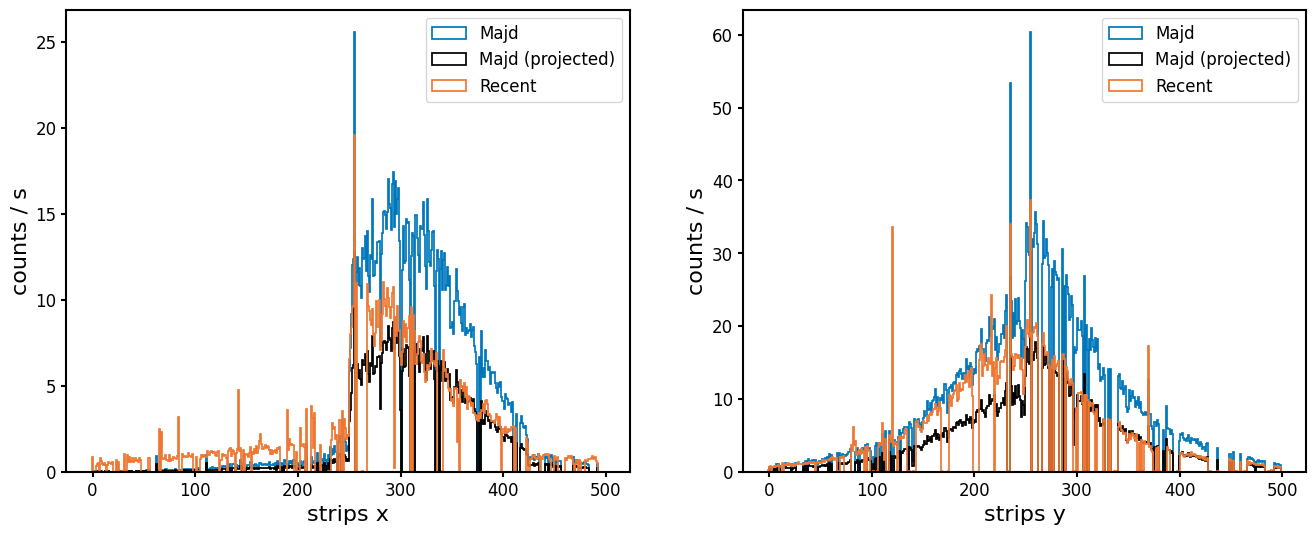

In [6]:
'''---------------------------------HIT RATE PLOTS---------------------------------'''
logscale = False

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
for i in range(0, len(df_hits_list)):
    xHits = df_hits_list[i].loc[df_hits_list[i]['plane'] == 0].reset_index()
    x_counts, x_bin_edges, x_patches = ax[0].hist(xHits['pos'], bins=strip_edges, histtype='step', color=hist_colors[i], weights=np.full(len(xHits), 1/data_duration_list[i]), label=hist_labels[i], linewidth=1.25)
    
    yHits = df_hits_list[i].loc[df_hits_list[i]['plane'] == 1].reset_index()
    y_counts, y_bin_edges, y_patches = ax[1].hist(yHits['pos'], bins=strip_edges, histtype='step', color=hist_colors[i], weights=np.full(len(yHits), 1/data_duration_list[i]), label=hist_labels[i], linewidth=1.25)

    if isMajdData[i] == True:
        xHits = df_hits_list[i].loc[df_hits_list[i]['plane'] == 0].reset_index()
        x_counts, x_bin_edges, x_patches = ax[0].hist(xHits['pos'], bins=strip_edges, histtype='step', color=hist_colors[i+5], weights=np.full(len(xHits), 1/(2*data_duration_list[i])), label='Majd (projected)', linewidth=1.25)
        
        yHits = df_hits_list[i].loc[df_hits_list[i]['plane'] == 1].reset_index()
        y_counts, y_bin_edges, y_patches = ax[1].hist(yHits['pos'], bins=strip_edges, histtype='step', color=hist_colors[i+5], weights=np.full(len(yHits), 1/(2*data_duration_list[i])), label='Majd (projected)', linewidth=1.25)

ax[0].legend(loc='upper right')
ax[0].set_xlabel("strips x")
ax[0].set_ylabel("counts / s")
ax[1].legend(loc='upper right')
ax[1].set_xlabel("strips y")
ax[1].set_ylabel("counts / s")

if logscale == True:
    ax[0].set_yscale("log")
    ax[1].set_yscale("log")

#ax[0].set_ylim(0, 6)
#ax[1].set_ylim(0, 6)

fig.savefig(f'plots/png/hit_rate.png', bbox_inches="tight")
fig.savefig(f'plots/pdf/hit_rate.pdf', bbox_inches="tight")

Majd a: 4021.3225371120097
Recent a: 4467.271352985637
Majd b: 4389.257142857143
Recent b: 5790.270270270271
Majd c: 4560.0
Recent c: 8416.39344262295
Majd d: 0
Recent d: 16538.46153846154


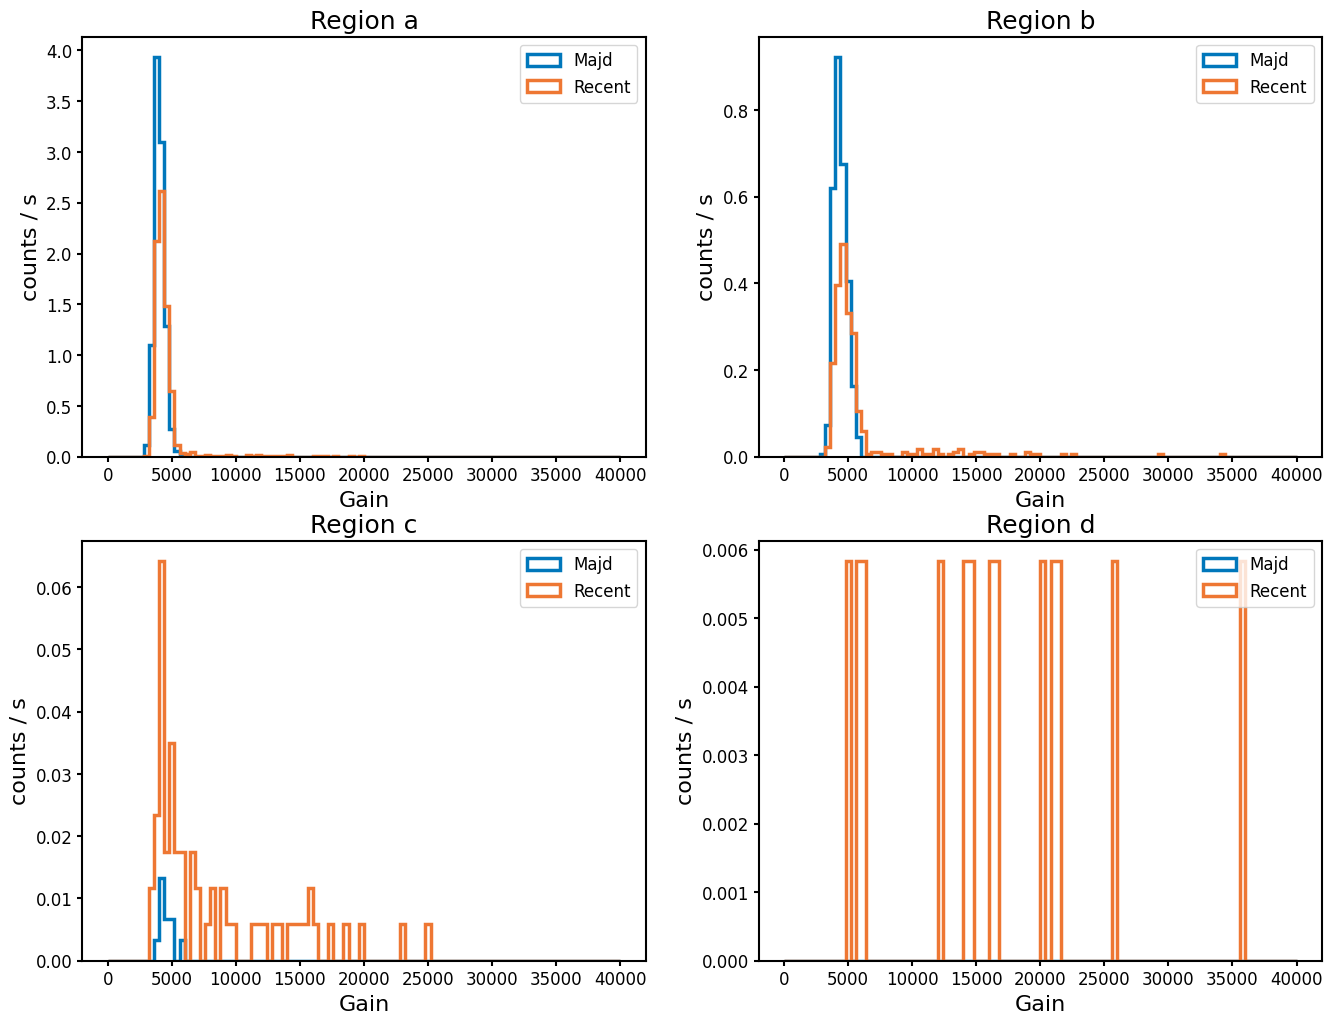

In [7]:
'''---------------------PLOT GAIN (by dataset) FOR EACH REGION---------------------'''
xaxis_minmax = (0, 40000)
logscale = False

fig, ax = plt.subplots(2, 2, figsize=(16, 12))
fid_areas = ['a', 'b', 'c', 'd'] #must be valid areas for fiducializeArea function in vmm_tools.py
for l in range(0, len(fid_areas)):
    for i in range(0, len(df_clusters_list)):
        counts, bin_edges, patches = histGain(ax[l//2, l%2], df_clusters_list[i], hist_colors[i], hist_labels[i], x_gains_list[i], y_gains_list[i], xaxis_minmax, fiducialize=True, fid_area=fid_areas[l], data_duration=data_duration_list[i])
        
        #For printing the mean gain for each region and dataset
        bin_midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2
        try:
            weighted_mean = np.average(bin_midpoints, weights=counts)
        except:
            weighted_mean = 0
        print(f"{hist_labels[i]} {fid_areas[l]}: {weighted_mean}")

    ax[l//2, l%2].legend(loc='upper right')
    ax[l//2, l%2].set_title(f'Region {fid_areas[l]}')
    ax[l//2, l%2].set_xlabel("Gain")
    ax[l//2, l%2].set_ylabel("counts / s")

    if logscale == True:
        ax[l//2, l%2].set_yscale("log")

    #ax[l//2, l%2].set_ylim(0, 0.004) #to get all files to have the same y-axis range for easier comparison, change as necessary
    #ax[l//2, l%2].set_xlim(2000, 15000) #to get all files to have the same x-axis range for easier comparison, change as necessary

fig.savefig(f'plots/png/gain_hist_by_region.png', bbox_inches="tight")
fig.savefig(f'plots/pdf/gain_hist_by_region.pdf', bbox_inches="tight")

Text(0, 0.5, 'Mean Gain')

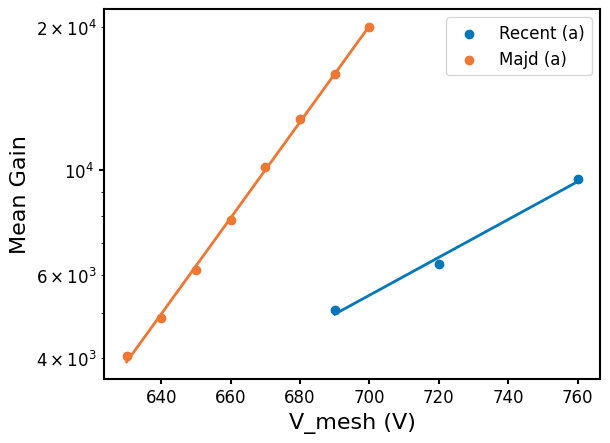

In [8]:
#with DLC
vmesh = [760, 720, 690]
mean_avalanch_gain = [9577.272727272724, 6328.484848484849, 5053.333333333333]
vmeshmajd = [700, 690, 680, 670, 660, 650, 640, 630]
mean_avalanch_gain_majd = [20010.60093675966, 15969.423836415312, 12803.801169590653, 10156.61242574929, 7831.198424998966, 6138.246078631098, 4865.234100582661, 4046.9741075532415]
fig, ax = plt.subplots()

ax.scatter(vmesh, mean_avalanch_gain, label='Recent (a)', color=hist_colors[0])
ax.scatter(vmeshmajd, mean_avalanch_gain_majd, label='Majd (a)', color=hist_colors[1])

# Fit in log-space
coeffs = np.polyfit(vmesh, np.log(mean_avalanch_gain), 1)
x_fit = np.linspace(min(vmesh), max(vmesh), 200)
y_fit = np.exp(np.polyval(coeffs, x_fit))
ax.plot(x_fit, y_fit, color=hist_colors[0])

coeffs = np.polyfit(vmeshmajd, np.log(mean_avalanch_gain_majd), 1)
x_fit = np.linspace(min(vmeshmajd), max(vmeshmajd), 200)
y_fit = np.exp(np.polyval(coeffs, x_fit))
ax.plot(x_fit, y_fit, color=hist_colors[1])

ax.set_yscale('log')
ax.legend(loc='upper right')
ax.set_xlabel('V_mesh (V)')
ax.set_ylabel('Mean Gain')

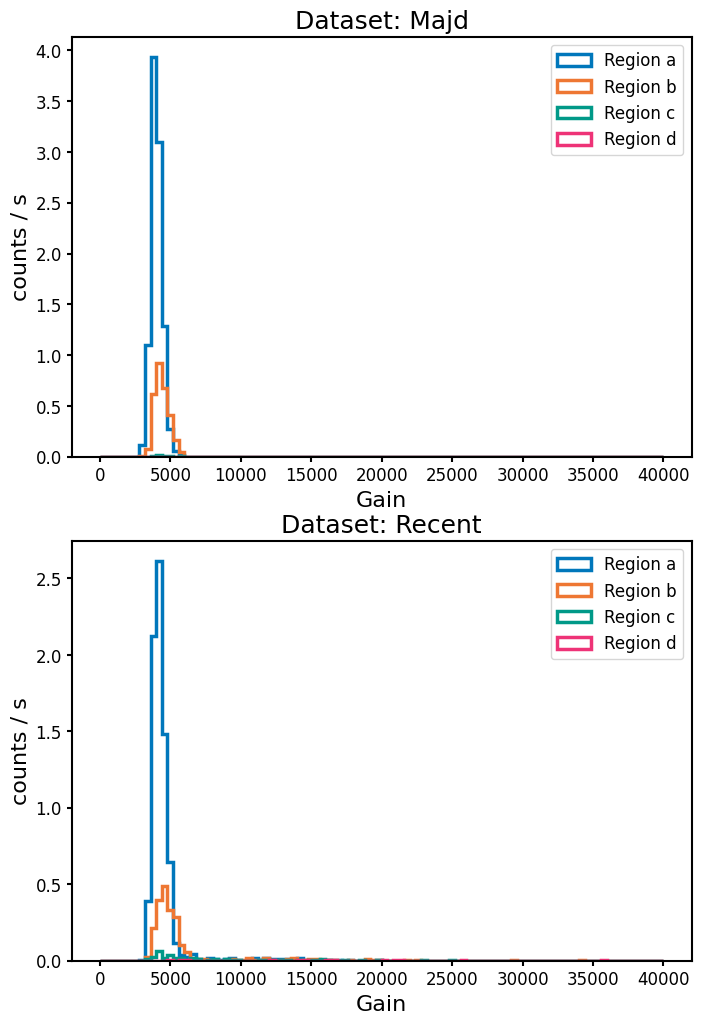

In [9]:
'''---------------------PLOT GAIN (by region) FOR EACH DATASET---------------------'''
xaxis_minmax = (0, 40000)

numDatasets = len(df_clusters_list)
fig, ax = plt.subplots(numDatasets, 1, figsize=(8, 6*numDatasets), squeeze=False)
for l in range(0, numDatasets):
    fid_areas = ['a', 'b', 'c', 'd']
    area_labels = ['Region a', 'Region b', 'Region c', 'Region d']
    for i in range(0, len(fid_areas)):
        counts, bin_edges, patches = histGain(ax[l, 0], df_clusters_list[l], hist_colors[i], area_labels[i], x_gains_list[l], y_gains_list[l], xaxis_minmax, fiducialize=True, fid_area=fid_areas[i], data_duration=data_duration_list[l])
    ax[l, 0].legend(loc='upper right')
    ax[l, 0].set_title(f'Dataset: {hist_labels[l]}')
    ax[l, 0].set_xlabel("Gain")
    ax[l, 0].set_ylabel("counts / s")
    #ax[l, 0].set_ylim(0, 0.004) #to get all files to have the same y-axis range for easier comparison, change as necessary
    #ax[l, 0].set_xlim(2000, 15000) #to get all files to have the same x-axis range for easier comparison, change as necessary

fig.savefig(f'plots/png/gain_hist_by_dataset.png', bbox_inches="tight")
fig.savefig(f'plots/pdf/gain_hist_by_dataset.pdf', bbox_inches="tight")

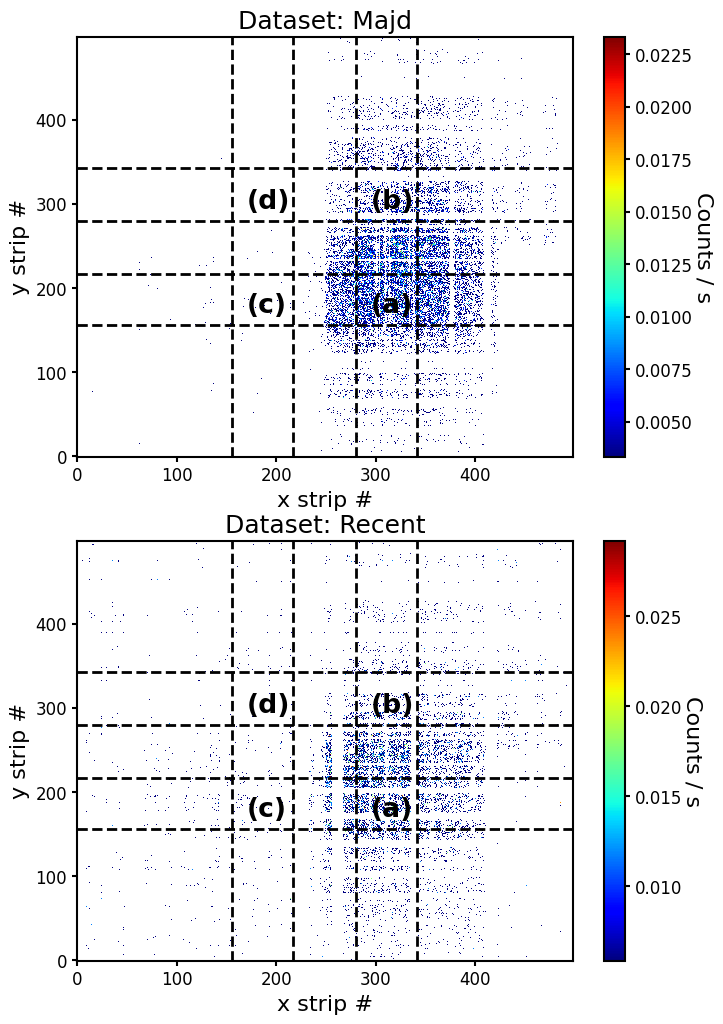

In [10]:
'''-----------------------------2D CLUSTER HISTOGRAM-----------------------------'''
logscale = False

numDatasets = len(df_clusters_list)
fig, ax = plt.subplots(numDatasets, 1, figsize=(8, 6*numDatasets), squeeze=False)
for i in range(0, numDatasets):
    hist, xedges, yedges, im = plotClusterLocations2D(ax[i, 0], df_clusters_list[i], strip_edges, data_duration_list[i], logscale=logscale)
    
    fiducialize_line_color = 'black'
    ax[i, 0].axvline(156,linestyle = "--", color=fiducialize_line_color)
    ax[i, 0].axvline(217,linestyle = "--", color=fiducialize_line_color)
    ax[i, 0].axvline(280,linestyle = "--", color=fiducialize_line_color)
    ax[i, 0].axvline(342,linestyle = "--", color=fiducialize_line_color)
    ax[i, 0].axhline(156,linestyle = "--", color=fiducialize_line_color)
    ax[i, 0].axhline(217,linestyle = "--", color=fiducialize_line_color)
    ax[i, 0].axhline(280,linestyle = "--", color=fiducialize_line_color)
    ax[i, 0].axhline(342,linestyle = "--", color=fiducialize_line_color)
    ax[i, 0].text(170.5,170.5,"(c)",color=fiducialize_line_color, fontsize="large", fontweight="bold")
    ax[i, 0].text(295,295,"(b)",color=fiducialize_line_color, fontsize="large", fontweight="bold")
    ax[i, 0].text(170.5,295,"(d)",color=fiducialize_line_color, fontsize="large", fontweight="bold")
    ax[i, 0].text(295,170.5,"(a)",color=fiducialize_line_color, fontsize="large", fontweight="bold")
    ax[i, 0].set_title(f'Dataset: {hist_labels[i]}')
    ax[i, 0].set_xlabel("x strip #")
    ax[i, 0].set_ylabel("y strip #")

    cbar = fig.colorbar(im, ax=ax[i, 0])
    cbar.set_label("Counts / s", rotation=270, labelpad=15)

fig.savefig(f'plots/png/2dhist_by_dataset.png', bbox_inches="tight")
fig.savefig(f'plots/pdf/2dhist_by_dataset.pdf', bbox_inches="tight")

In [11]:
'''---------------------------------CHARGE SHARING---------------------------------'''

for l in range(0, len(df_clusters_list)):
    fid_areas = ['a', 'b', 'c', 'd']
    for i in range(0, len(fid_areas)):
        charge_sharing = calculateChargeSharing(df_clusters_list[l], x_gains_list[l], y_gains_list[l], fiducialize=True, fid_area=fid_areas[i])
        print(f'Data set {hist_labels[l]}, region {fid_areas[i]}, x={x_gains_list[l]} mV/fC, y={y_gains_list[l]} mV/fC preamp gain ---> CS = {charge_sharing}')

Data set Majd, region a, x=9.0 mV/fC, y=4.5 mV/fC preamp gain ---> CS = 0.5491946412639411
Data set Majd, region b, x=9.0 mV/fC, y=4.5 mV/fC preamp gain ---> CS = 0.4226102267698408
Data set Majd, region c, x=9.0 mV/fC, y=4.5 mV/fC preamp gain ---> CS = 0.41109790110327743
Data set Majd, region d, x=9.0 mV/fC, y=4.5 mV/fC preamp gain ---> CS = nan
Data set Recent, region a, x=9.0 mV/fC, y=4.5 mV/fC preamp gain ---> CS = 0.5550521398956976
Data set Recent, region b, x=9.0 mV/fC, y=4.5 mV/fC preamp gain ---> CS = 0.4388362591687511
Data set Recent, region c, x=9.0 mV/fC, y=4.5 mV/fC preamp gain ---> CS = 0.41583597323721194
Data set Recent, region d, x=9.0 mV/fC, y=4.5 mV/fC preamp gain ---> CS = 0.9698244048542625
